# Sentiment Analysis of Financial Dataset 
by GPT-OSS:2b0b


## Putting the Different Prompts into Action

Loading data and preparing for ablation study...
Starting Ablation Study for 15 prompts on 80 samples...
Testing P1_ZeroShot...


  0%|          | 0/80 [00:00<?, ?it/s]

Testing P2_Constrained...


  0%|          | 0/80 [00:00<?, ?it/s]

Testing P3_RolePlay...


...

  0%|          | 0/80 [00:00<?, ?it/s]

Testing P15_Ultimate...


  0%|          | 0/80 [00:00<?, ?it/s]


Ablation Study Results:
Prompt Strategy  Accuracy  Macro-F1
 P2_Constrained    0.7875  0.768952
    P1_ZeroShot    0.7625  0.753247
         P6_CoT    0.7500  0.738693
   P10_Keywords    0.7500  0.764784
       P13_Risk    0.7500  0.729064
    P3_RolePlay    0.7375  0.738269
     P5_FewShot    0.7125  0.701895
 P8_Definitions    0.7125  0.699458
   P15_Ultimate    0.7000  0.701432
P14_FutureFocus    0.6875  0.682875
P11_Contrastive    0.6500  0.591667
    P7_Role_CoT    0.6375  0.630085
      P9_Action    0.6125  0.636051
     P4_OneShot    0.5500  0.535714
     P12_Nuance    0.5125  0.527546


/var/folders/vc/3kfwh15d7234657gp2jqxqj80000gn/T/ipykernel_7957/893723620.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Accuracy", y="Prompt Strategy", palette="viridis")


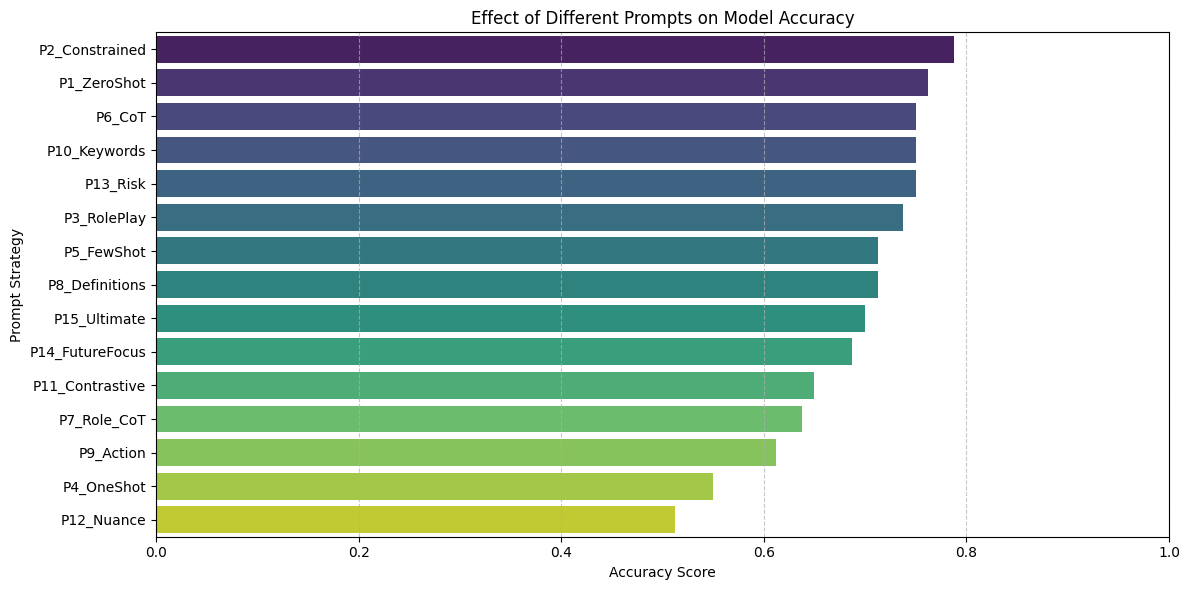

['negative', 'positive', 'neutral', 'neutral', 'positive', 'negative', 'positive', 'negative', 'neutral', 'negative', 'neutral', 'neutral', 'neutral', 'positive', 'positive', 'positive', 'positive', 'neutral', 'neutral', 'neutral', 'neutral', 'positive', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'positive', 'neutral', 'neutral', 'positive', 'positive', 'neutral', 'negative', 'neutral', 'positive', 'positive', 'positive', 'negative', 'neutral', 'positive', 'neutral', 'neutral', 'positive', 'positive', 'positive', 'positive', 'positive', 'negative', 'positive', 'neutral', 'positive', 'positive', 'positive', 'neutral', 'positive', 'positive', 'negative', 'positive', 'positive', 'neutral', 'positive', 'neutral', 'negative', 'positive', 'neutral', 'positive', 'positive', 'positive', 'positive', 'negative', 'positive', 'neutral', 'positive', 'neutral', 'neutral', 'neutral', 'positive', 'negative', 'neutral']

 GPT-OSS (20B) PERFORMANCE METRICS 
Accuracy: 0.7000
Macro-F1 Score: 0

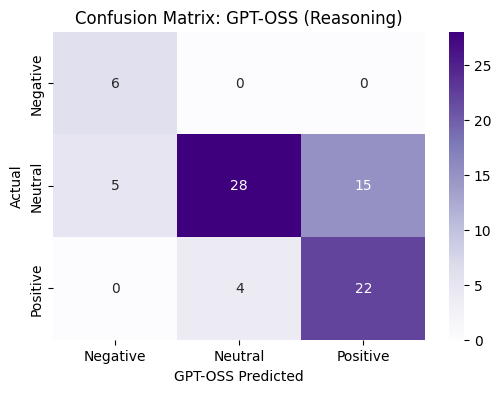

In [38]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
import requests
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pydantic import BaseModel, Field
from typing import Literal
import json 


# Model and port configuration
OLLAMA_URL = "http://localhost:11434/api/generate" 
MODEL_NAME = "gpt-oss:20b-cloud"

#Literal means the model can pick just one of the given options
class SentimentResponse(BaseModel):
    reasoning: str = Field(..., alias="Financial Reasoning")
    final_label: Literal['positive', 'negative', 'neutral'] = Field(..., alias="Final Label")

schema=SentimentResponse.model_json_schema()

print("Loading data and preparing for ablation study...")

# Reading the dataset, removing duplicates, and preparing train/val/test splits
df = pd.read_csv('./resources/cn7050data.csv', encoding='latin-1', names=['sentiment', 'text'])
df = df.drop_duplicates().reset_index(drop=True).dropna()
df['sentiment'] = df['sentiment'].str.lower()
df['text'] = df['text'].str.replace(r'[^\x00-\x7F]+', '[UNK]', regex=True)

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['sentiment'])

gpt_test_df = test_df.sample(n=80, random_state=13).copy()


# training on all the data. in the test less samples were tried by --> gpt_test_df.head(10)
#test_batch = gpt_test_df.head(10).copy()
test_batch = gpt_test_df

# Selection of 15 prompts for ablation study.
prompts_dict = {
    "P1_ZeroShot": "What is the sentiment of this headline: '{text}'? \nFinal Label: [positive/negative/neutral]",
    "P2_Constrained": "Classify the sentiment of this headline strictly as positive, negative, or neutral: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P3_RolePlay": "You are a Wall Street expert. Classify this headline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P4_OneShot": "Headline: 'Profits fell 20%'. Sentiment: negative. \nHeadline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P5_FewShot": "H: 'Growth is steady'. L: positive. \nH: 'Layoffs announced'. L: negative. \nH: 'Meeting is at 5PM'. L: neutral. \nH: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P6_CoT": "Think step-by-step about this headline: '{text}'. Explain your thoughts, then output: \nFinal Label: [positive/negative/neutral]",
    "P7_Role_CoT": "As a financial analyst, reason step-by-step about this headline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P8_Definitions": "Positive=profit/growth, Negative=loss/layoffs, Neutral=standard ops. Classify: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P9_Action": "Would an investor buy(positive), sell(negative), or hold(neutral) based on this: '{text}'? \nFinal Label: [positive/negative/neutral]",
    "P10_Keywords": "Extract 3 key financial words from '{text}', then determine sentiment. \nFinal Label: [positive/negative/neutral]",
    "P11_Contrastive": "Argue why '{text}' might be positive, then why it might be negative. Then decide. \nFinal Label: [positive/negative/neutral]",
    "P12_Nuance": "Look for subtle financial nuances in '{text}'. Is it truly good or bad? \nFinal Label: [positive/negative/neutral]",
    "P13_Risk": "Assess the financial risk in '{text}', then assign sentiment. \nFinal Label: [positive/negative/neutral]",
    "P14_FutureFocus": "Does the text: '{text}' --> imply positive future growth or negative decline? \nFinal Label: [positive/negative/neutral]",
    #"P15_Ultimate": "You are a financial AI. Step 1: Analyze '{text}'. Step 2: Use definitions (pos=gain, neg=loss). Step 3: Conclude. \nFinal Label: [positive/negative/neutral]"
    "P15_Ultimate": """You are an expert financial analyst. Read the following financial news headline and determine its sentiment.
    Headline: '{text}'

            Step 1: Analyze the financial implications of this headline. (Is it about growth, loss, standard operations, etc.?)
            Step 2: Based on your analysis, decide if the sentiment is strictly Positive, Negative, or Neutral.

            Provide your output in exactly this format:
            \nReasoning: [...]
            \nFinal Label: [positive / negative / neutral]
            """
}

# The function to call Ollama API.
def call_ollama(prompt_text):
    json_instruction = "\n\nYou MUST respond ONLY with a raw JSON object. Do NOT use markdown code blocks (```json). Just output the raw curly braces. Keys must be 'reasoning' and 'final_label'."    
    payload = {
        "model": MODEL_NAME, 
        "prompt": prompt_text + json_instruction,
        "stream": False,
        "format": "json",
        "options": {"temperature": 0.0}
    }
    try:
        res = requests.post(OLLAMA_URL, json=payload,timeout=30)
        res.raise_for_status()
        
        full_response_json = res.json()
        res_text = full_response_json.get("response", "").strip()
        
        clean_json_text = res_text
        
        json_match= re.search(r"\{.*\}", res_text, re.DOTALL)
        if json_match:
            clean_json_text = json_match.group(0)
        else:
            print(" [Warning] No JSON object found in response. Using entire response as fallback.")
            clean_json_text = res_text # Use res_text as the potential JSON string

        try:
            data = json.loads(clean_json_text)
            label = str(data.get("final_label", "neutral")).lower()
            reasoning = str(data.get("reasoning", ""))
        except (json.JSONDecodeError, TypeError):
            
            print(f" [Warning] this prompt has problem: 🟧--> {prompt_text}")
            print(" [Warning] JSON format failed. Using Regex fallback...")
            label_match = re.search(r"(positive|negative|neutral)", res_text, re.IGNORECASE)
            if label_match:
                label = label_match[-1].lower()
            else:
                label = "neutral"
            reasoning = "JSON failed. Extracted via Regex. Raw: " + res_text[:50]
        
        if label not in ['positive', 'negative', 'neutral']:
            print(f" [Warning] Invalid label '{label}' extracted. Defaulting to 'neutral'.")
            label = "neutral"
            
        return label, reasoning
    
    except Exception as e:
        print(f"\nAPI Error: {e}")
        return "neutral", "Error"

results_list = []
true_labels = test_batch['sentiment'].tolist()

print(f"Starting Ablation Study for {len(prompts_dict)} prompts on {len(test_batch)} samples...")

# running ollama for every prompt and collecting predictions to calculate accuracy and macro-f1 scores.
for prompt_name, prompt_template in prompts_dict.items():
    print(f"Testing {prompt_name}...")
    current_predictions = []
    
    for i, text in enumerate(tqdm(test_batch['text'], leave=False)):
        formatted_prompt = prompt_template.format(text=text)
        label,reasoning = call_ollama(formatted_prompt)
        #print(label)
        # if i==0:
        #     print(f"\n[DEBUG] {prompt_name} -> Model output: {label}")
        #     print(f"[DEBUG] Reasoning: {reasoning[:100]}...\n")            
        
        current_predictions.append(label)
    
    acc = accuracy_score(true_labels, current_predictions)
    f1 = f1_score(true_labels, current_predictions, average='macro')
    results_list.append({
        "Prompt Strategy": prompt_name,
        "Accuracy": acc,
        "Macro-F1": f1
    })

# Dataframe from results
results_df = pd.DataFrame(results_list).sort_values(by="Accuracy", ascending=False)
print("\nAblation Study Results:")
print(results_df.to_string(index=False))

#Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Accuracy", y="Prompt Strategy", palette="viridis")
plt.title('Effect of Different Prompts on Model Accuracy')
plt.xlabel('Accuracy Score')
plt.ylabel('Prompt Strategy')
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report, confusion_matrix

print(current_predictions)

print("\n" + "="*40)
print(" GPT-OSS (20B) PERFORMANCE METRICS ")
print("="*40)
print(f"Accuracy: {accuracy_score(true_labels, current_predictions):.4f}")
print(f"Macro-F1 Score: {f1_score(true_labels, current_predictions, average='macro'):.4f}")

print("\n--- Detailed Per-Class Report ---")
print(classification_report(true_labels, current_predictions, target_names=['negative', 'neutral', 'positive']))

cm = confusion_matrix(true_labels, current_predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('GPT-OSS Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: GPT-OSS (Reasoning)')
plt.show()


  Prompt Strategy    Metric   Score
0  P2_Constrained  Accuracy  0.7875
1     P1_ZeroShot  Accuracy  0.7625
2          P6_CoT  Accuracy  0.7500
3    P10_Keywords  Accuracy  0.7500
4        P13_Risk  Accuracy  0.7500


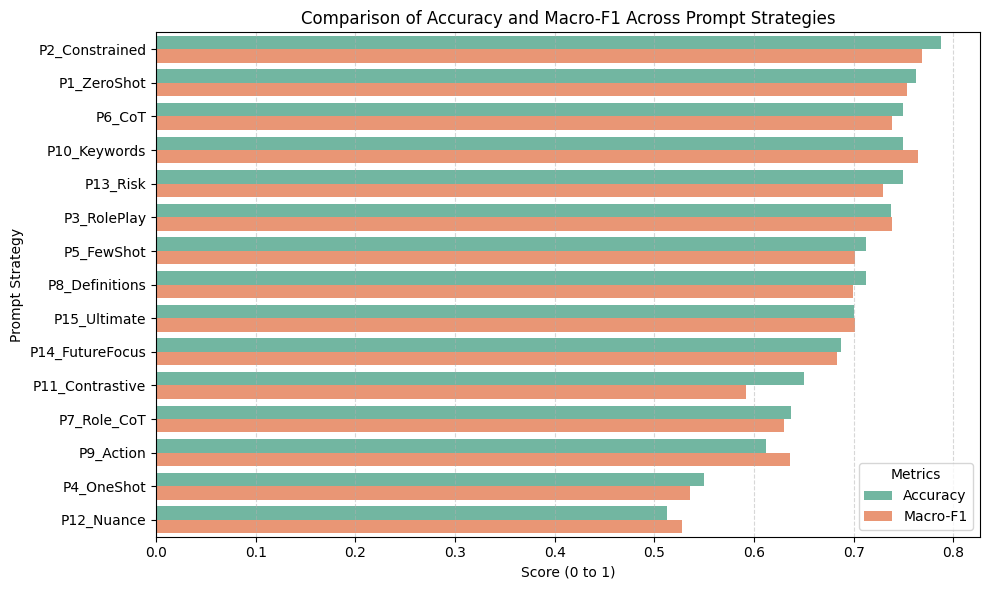

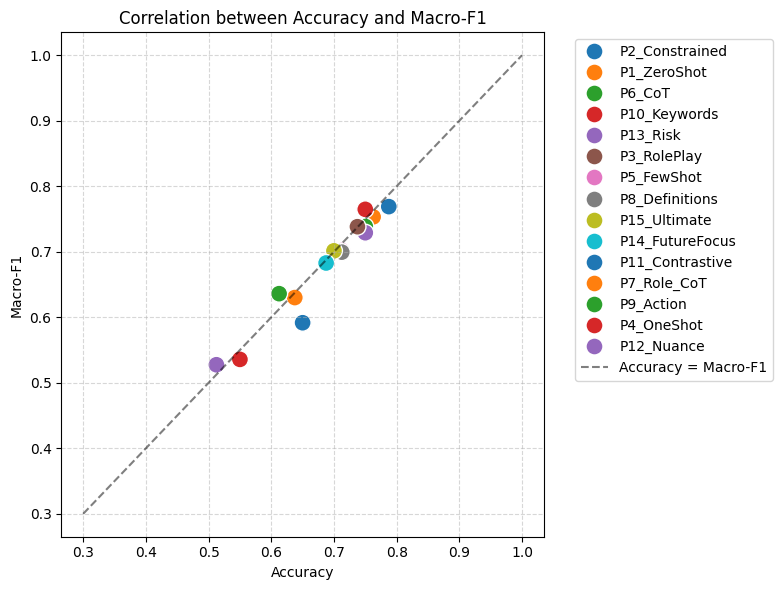

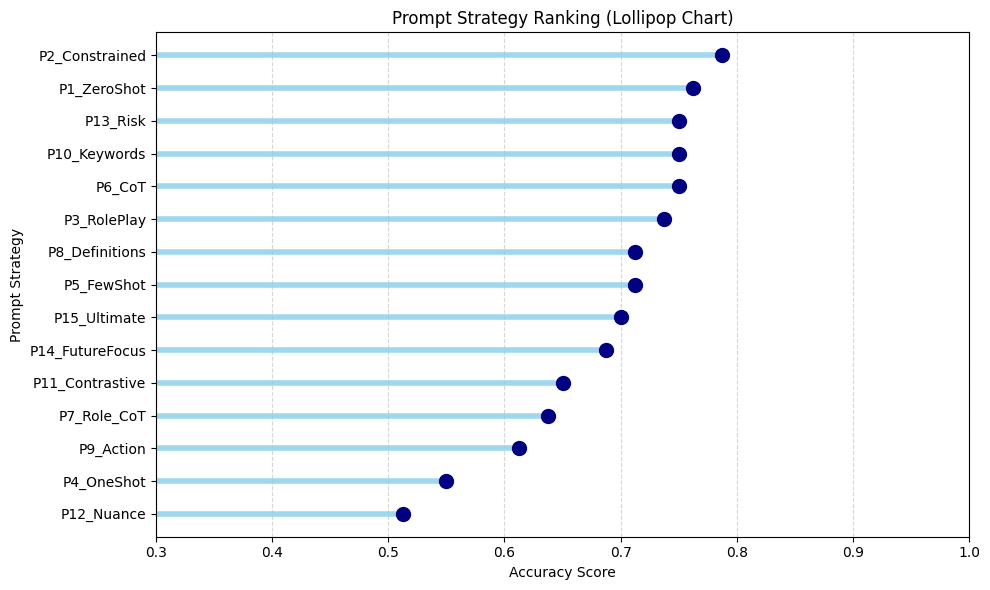

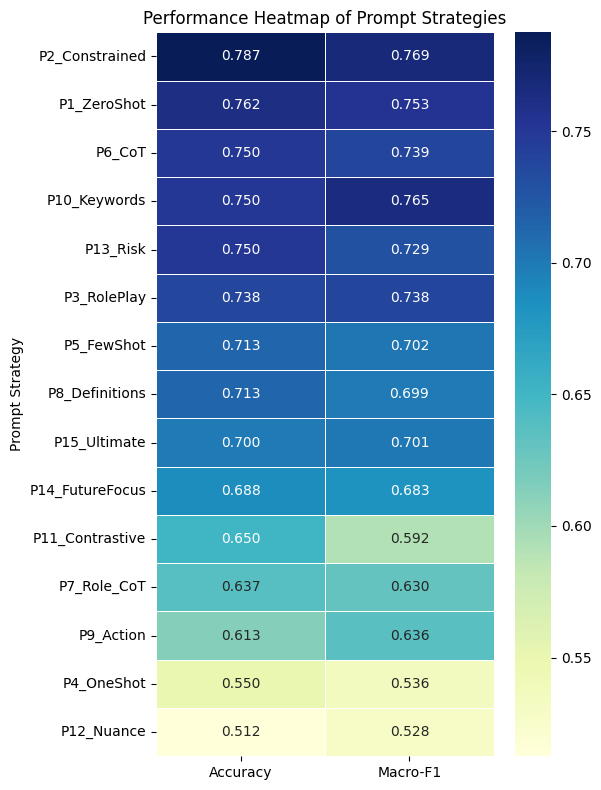

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# preparing the data
results_melted = results_df.melt(id_vars="Prompt Strategy", var_name="Metric", value_name="Score")

print(results_melted[results_melted['Metric'] == 'Accuracy'].sort_values(by=["Score"], ascending=False).head())

plt.figure(figsize=(10, 6))

sns.barplot(data=results_melted, y="Prompt Strategy", x="Score", hue="Metric", palette="Set2")

plt.title("Comparison of Accuracy and Macro-F1 Across Prompt Strategies")
plt.xlabel("Score (0 to 1)")
plt.ylabel("Prompt Strategy")
plt.legend(loc='lower right', title="Metrics")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
# رسم نقاط
sns.scatterplot(data=results_df, x="Accuracy", y="Macro-F1", hue="Prompt Strategy", s=150, palette="tab10")

# a diagonal line to make it more visible
plt.plot([0.3, 1.0], [0.3, 1.0], 'k--', alpha=0.5, label='Accuracy = Macro-F1')

plt.title("Correlation between Accuracy and Macro-F1")
plt.xlabel("Accuracy")
plt.ylabel("Macro-F1")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


results_sorted = results_df.sort_values(by="Accuracy", ascending=True)

plt.figure(figsize=(10, 6))

plt.hlines(y=results_sorted['Prompt Strategy'], xmin=0, xmax=results_sorted['Accuracy'], color='skyblue', alpha=0.8, linewidth=4)

plt.plot(results_sorted['Accuracy'], results_sorted['Prompt Strategy'], "o", markersize=10, color='navy')

plt.title("Prompt Strategy Ranking (Lollipop Chart)")
plt.xlabel("Accuracy Score")
plt.ylabel("Prompt Strategy")
plt.xlim(0.3, 1.0) 
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 8))

heatmap_data = results_df.set_index("Prompt Strategy")[["Accuracy", "Macro-F1"]].sort_values(by="Accuracy", ascending=False)

sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", cbar=True, fmt=".3f", linewidths=.5)

plt.title("Performance Heatmap of Prompt Strategies")
plt.tight_layout()
plt.show()


# Final 

In [9]:
import torch
import pandas as pd
import requests
import json
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score


OLLAMA_URL = "http://localhost:11434/api/chat" 
MODEL_NAME = "gpt-oss:20b-cloud"
df = pd.read_csv('./resources/cn7050data.csv', encoding='latin-1', names=['sentiment', 'text'])
df = df.drop_duplicates().reset_index(drop=True).dropna()
df['sentiment'] = df['sentiment'].str.lower()
df['text'] = df['text'].str.replace(r'[^\x00-\x7F]+', '[UNK]', regex=True)

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['sentiment'])

gpt_test_df = test_df.sample(n=80, random_state=13).copy()




In [10]:

def build_reasoning_prompt(text, gold_label):
    # Keep explanation SHORT and CONCRETE to avoid rambling
    system = (
        "You are a financial NLP assistant. "
        "Classify the sentiment of the provided news as Positive, Negative, or Neutral. "
        "Then give a SHORT, concrete explanation citing the phrases that led you there."
    )
    user = f"""News:
{text}

            Instructions:
            1) Decide the sentiment strictly from the news content.
            2) Keep the explanation to 1-3 sentences, focusing on evidence (numbers, direction, outcomes).
            3) Output JSON with keys: predicted_label, explanation.
            """
    return system, user

def gpt_oss_chat_json(system, user, temperature=0.2, top_p=0.9):
    import re
    # Requires `model` and `tokenizer` to be defined in the runtime, as per the original notebook.
    payload={
        "model": MODEL_NAME,
        "messages": [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
        ],
        "format": "json",
        "stream":False,
        "options": {"temperature": temperature, "top_p": top_p}
    }
    
    reply = ""
    try:
        #print( "1️⃣ before getting the model")
        res = requests.post(OLLAMA_URL, json=payload)
        res.raise_for_status()
        #print(" 2️⃣ after getting the model")
        # Safely extract message content
        msg_data = res.json().get("message", {})
        #print(f" 3️⃣ : {msg_data}")
        if isinstance(msg_data, dict):
            reply = msg_data.get("content", "").strip()
        else:
            reply = str(msg_data).strip()
            
        # Try to find JSON structure in the response text in case there's preamble
        json_match = re.search(r"\{.*\}", reply, re.DOTALL)
        clean_json_str = json_match.group(0) if json_match else reply
        
        data = json.loads(clean_json_str)
        return data, reply
        
    except Exception as e:
        print(f" 🟧 API Error: {e} | Raw Reply: {reply[:100]}")
        return {"predicted_label": None, "explanation": f"Failed to parse JSON. Raw output saved."}, reply if reply else "No output"
        

def run_reasoning(df, sample_size=None):
    data = df if sample_size is None else df.sample(sample_size, random_state=42).reset_index(drop=True)
    records = []
    
    for i, row in tqdm(data.iterrows(), total=len(data)):
        gold = str(row["sentiment"]).strip().lower()
        text = str(row["text"]).strip()
        sys, usr = build_reasoning_prompt(text, gold)
        js, raw = gpt_oss_chat_json(sys, usr)
        pred = (js.get("predicted_label") or "").strip().lower()
        exp = js.get("explanation") or ""
        records.append({
            "text": text,
            "gold_label": gold,
            "predicted_label": pred,
            "explanation": exp,
            "raw_model_output": raw,
        })
    return pd.DataFrame(records)


In [11]:

# --- 4) Run on the whole dataset or a sample ---
# Tip: start with a small sample to validate formatting, then scale.
#SAMPLE = 0   # set to None for full dataset

results_df = run_reasoning(gpt_test_df,sample_size=None)#, sample_size=SAMPLE)

# Simple accuracy if model outputs labels properly
def normalise_label(x):
    x = (x or "").lower()
    if "pos" in x: return "positive"
    if "neg" in x: return "negative"
    if "neu" in x: return "neutral"
    return x

results_df["predicted_label_norm"] = results_df["predicted_label"].map(normalise_label)
results_df["gold_label_norm"] = results_df["gold_label"].map(normalise_label)
acc = (results_df["predicted_label_norm"] == results_df["gold_label_norm"]).mean()

print(f"Sample size: {len(results_df)}")
print(f"Exact label match (normalised): {acc:.3f}")
results_df.head(5)


  0%|          | 0/80 [00:00<?, ?it/s]

Sample size: 80
Exact label match (normalised): 0.787


,text,gold_label,predicted_label,explanation,raw_model_output,predicted_label_norm,gold_label_norm
0,The company reported today an operating loss o...,negative,negative,The report states the company incurred an oper...,"{""predicted_label"":""Negative"",""explanation"":""T...",negative,negative
1,Finnish property investor Sponda said it has a...,neutral,positive,The article reports that Sponda secured a €100...,"```json\n{\n ""predicted_label"": ""Positive"",\n...",positive,neutral
2,Implementation of the project will be carried ...,neutral,neutral,The text merely states that YIT and EPI will i...,"```json\n{\n ""predicted_label"": ""Neutral"",\n ...",neutral,neutral
3,"It would be premature to talk about dates , vo...",neutral,neutral,The statement expresses uncertainty and a lack...,"{""predicted_label"":""Neutral"",""explanation"":""Th...",neutral,neutral
4,Etteplan targets to employ at least 20 people ...,positive,positive,The article states that Etteplan plans to empl...,"```json\n{\n ""predicted_label"": ""Positive"",\n...",positive,positive


In [ ]:
print(results_df["raw_model_output"].iloc[0])

{"predicted_label":"Negative","explanation":"The report states the company incurred an operating loss of EUR 0.1 m, indicating a negative financial outcome."}


In [12]:

# --- 5) Save results for review ---
OUT_CSV = "./resources/anwesha_given_code_results.csv"
results_df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)


Saved: ./resources/anwesha_given_code_results.csv


In [13]:

# --- (Optional) 6) Inspect a single row interactively ---
ROW_INDEX = 6  # change this
row = gpt_test_df.iloc[ROW_INDEX]
sys, usr = build_reasoning_prompt(str(row['text']), str(row['sentiment']))
js, raw = gpt_oss_chat_json(sys, usr)
print("GOLD:", row['sentiment'])
print("MODEL:", js.get("predicted_label"))
print("EXPLANATION:", js.get("explanation"))


GOLD: neutral
MODEL: Neutral
EXPLANATION: The article merely reports that donations have been granted to several universities and polytechnics, with no evaluative or emotional language indicating positive or negative sentiment.


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

OUT_CSV = "./resources/anwesha_given_code_results.csv"

df_results=pd.read_csv(OUT_CSV)
#print(df_results.head(4))
print(classification_report(df_results['gold_label_norm'], df_results['predicted_label_norm'], target_names=['negative', 'neutral', 'positive']))
confusion_matrix(df_results['gold_label_norm'], df_results['predicted_label_norm'])


              precision    recall  f1-score   support

    negative       0.50      1.00      0.67         6
     neutral       0.88      0.75      0.81        48
    positive       0.78      0.81      0.79        26

    accuracy                           0.79        80
   macro avg       0.72      0.85      0.76        80
weighted avg       0.82      0.79      0.79        80



array([[ 6,  0,  0],
       [ 6, 36,  6],
       [ 0,  5, 21]])

# Combination of the best prompts

In [21]:
import torch
import pandas as pd
import requests
import json
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score


OLLAMA_URL = "http://localhost:11434/api/chat" 
MODEL_NAME = "gpt-oss:20b-cloud"
df = pd.read_csv('./resources/cn7050data.csv', encoding='latin-1', names=['sentiment', 'text'])
df = df.drop_duplicates().reset_index(drop=True).dropna()
df['sentiment'] = df['sentiment'].str.lower()
df['text'] = df['text'].str.replace(r'[^\x00-\x7F]+', '[UNK]', regex=True)

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['sentiment'])

gpt_test_df = test_df.sample(n=3, random_state=13).copy()


In [26]:
prompts_dict = {
    "P1_Lecturer_Fixed": {
        "system": "You are a financial NLP assistant. Classify the sentiment of the provided news as Positive, Negative, or Neutral. Then give a SHORT, concrete explanation citing the phrases that led you there.",
        "user": "News:\n{text}\n\nInstructions:\n1) Decide the sentiment strictly from the news content.\n2) Keep the explanation to 1-3 sentences, focusing on evidence.\n3) Output JSON with keys: 'predicted_label' and 'explanation'."
    },
    
    "P2_Constrained": {
        "system": "You are a rigid, emotionless financial trading algorithm. Classify the sentiment strictly as Positive, Negative, or Neutral.",
        "user": "News:\n{text}\n\nInstructions:\n1) Classify the sentiment strictly as positive, negative, or neutral. Do not overthink.\n2) Output JSON with keys: 'predicted_label' and 'explanation'. (For explanation, simply write 'Strict classification applied')."
    },
    
    "P3_Hybrid_Master": {
        "system": "You are an expert financial NLP assistant. Classify financial sentiment strictly. Rules: Positive = explicit financial gain/growth. Negative = loss/decline/penalty. Neutral = standard corporate operations, partnerships, or PR.",
        "user": "News:\n{text}\n\nInstructions:\n1) Decide the sentiment strictly using the defined rules.\n2) Give a SHORT, 1-2 sentence explanation focusing ONLY on concrete financial evidence.\n3) Output JSON with keys: 'predicted_label' and 'explanation'."
    },
    
    "P4_Baseline_ZeroShot": {
        "system": "You are a helpful AI assistant.",
        "user": "Classify the sentiment of this headline as Positive, Negative, or Neutral.\n\nHeadline: '{text}'\n\nOutput JSON with keys: 'predicted_label' and 'explanation'."
    }
}

In [ ]:
def call_ollama(system_prompt, user_prompt):
    # payload
    payload={
        "model": MODEL_NAME,
        "messages": [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
        ],
        "format": "json",
        "stream": False,
        "options": {"temperature": 0.0}
    }
    try:
        res= requests.post(OLLAMA_URL, json=payload)
        res.raise_for_status()
        reply = res.json().get("message", {}).get("content", "").strip()
        
        json_match = re.search(r"\{.*\}", reply, re.DOTALL)
        clean_json_text = json_match.group(0) if json_match else reply
        try:
            data=json.loads(clean_json_text)
            label= str(data.get("predicted_label","neutral")).strip().lower()
            explanation=str(data.get("explanation",""))
        except Exception:
            matches = re.findall(r"(positive|negative|neutral)", reply, re.IGNORECASE)
            label = matches[-1].lower() if matches else "neutral"
            explanation = "JSON failed. Extracted via Regex."
            
        if label not in ['positive', 'negative', 'neutral']:
            label = "neutral"
        return label , explanation
    
    except Exception as e:
        return "neutral" , f"Error: {e}"
            
results_list = []
detailed_results = {}

print(f"Starting System/User Prompt Study on {len(gpt_test_df)} samples...\n")
true_labels = gpt_test_df['sentiment'].tolist()

for prompt_name, prompt_data in prompts_dict.items():
    current_predictions=[]
    #print(f"Testing Prompt Strategy: {prompt_name}...")
    
    for text in tqdm(gpt_test_df['text'], leave=False):
        formatted_user=prompt_data["user"].format(text=text)
        #print(f"\n1️⃣ before getting the model for prompt: {formatted_user[:80]}...")
        label,explanation=call_ollama(prompt_data['system'],formatted_user)
        #print(f" 2️⃣ after getting the model")
        current_predictions.append(label)
    #print(f"3️⃣ Completed")
    
    detailed_results[prompt_name] = current_predictions
    
    acc = accuracy_score(true_labels, current_predictions)
    f1 = f1_score(true_labels, current_predictions, average='macro')
    
    results_list.append({
        "Prompt Strategy": prompt_name,
        "Accuracy": acc,
        "Macro-F1": f1
    })
results_df = pd.DataFrame(results_list).sort_values(by="Accuracy", ascending=False)

print("\n=== FINAL RESULTS ===\n\n")
print(results_df.to_string(index=False))

# Pick the best prompt to show the detailed report
best_prompt = results_df.iloc[0]["Prompt Strategy"]
print(f"\n=== DETAILED REPORT FOR BEST PROMPT: {best_prompt} ===")

#print(classification_report(true_labels, detailed_results[best_prompt], target_names=['negative', 'neutral', 'positive']))
# print(classification_report(
#     true_labels, 
#     detailed_results[best_prompt], 
#     labels=['negative', 'neutral', 'positive'],
#     target_names=['negative', 'neutral', 'positive'],
#     zero_division=0                                  
# ))

Starting System/User Prompt Study on 3 samples...

Testing Prompt Strategy: P1_Lecturer_Fixed...


  0%|          | 0/3 [00:00<?, ?it/s]


1️⃣ before getting the model for prompt: News:
The company reported today an operating loss of EUR0 .1 m on net sales of ...
 2️⃣ after getting the model

1️⃣ before getting the model for prompt: News:
Finnish property investor Sponda said it has agreed a 100 mln eur , five-y...
 2️⃣ after getting the model

1️⃣ before getting the model for prompt: News:
Implementation of the project will be carried out by the Finnish company Y...
 2️⃣ after getting the model
3️⃣ Completed
Testing Prompt Strategy: P2_Constrained...


  0%|          | 0/3 [00:00<?, ?it/s]


1️⃣ before getting the model for prompt: News:
The company reported today an operating loss of EUR0 .1 m on net sales of ...
 2️⃣ after getting the model

1️⃣ before getting the model for prompt: News:
Finnish property investor Sponda said it has agreed a 100 mln eur , five-y...
 2️⃣ after getting the model

1️⃣ before getting the model for prompt: News:
Implementation of the project will be carried out by the Finnish company Y...
 2️⃣ after getting the model
3️⃣ Completed
Testing Prompt Strategy: P3_Hybrid_Master...


  0%|          | 0/3 [00:00<?, ?it/s]


1️⃣ before getting the model for prompt: News:
The company reported today an operating loss of EUR0 .1 m on net sales of ...
 2️⃣ after getting the model

1️⃣ before getting the model for prompt: News:
Finnish property investor Sponda said it has agreed a 100 mln eur , five-y...
 2️⃣ after getting the model

1️⃣ before getting the model for prompt: News:
Implementation of the project will be carried out by the Finnish company Y...
 2️⃣ after getting the model
3️⃣ Completed
Testing Prompt Strategy: P4_Baseline_ZeroShot...


  0%|          | 0/3 [00:00<?, ?it/s]


1️⃣ before getting the model for prompt: Classify the sentiment of this headline as Positive, Negative, or Neutral.

Head...
 2️⃣ after getting the model

1️⃣ before getting the model for prompt: Classify the sentiment of this headline as Positive, Negative, or Neutral.

Head...
 2️⃣ after getting the model

1️⃣ before getting the model for prompt: Classify the sentiment of this headline as Positive, Negative, or Neutral.

Head...
 2️⃣ after getting the model
3️⃣ Completed

=== FINAL RESULTS ===


     Prompt Strategy  Accuracy  Macro-F1
   P1_Lecturer_Fixed  0.666667       0.4
      P2_Constrained  0.666667       0.4
    P3_Hybrid_Master  0.666667       0.4
P4_Baseline_ZeroShot  0.666667       0.4

=== DETAILED REPORT FOR BEST PROMPT: P1_Lecturer_Fixed ===
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
     neutral       0.67      1.00      0.80         2
    positive       0.00      0.00      0.00         0

    accuracy 